#Trabalho final de Recomendação de sistema

Charlie Prince de Souza Andrade

Julia da Silva Borges

## Preparação dos Dados

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import time

### CARREGAMENTO DO DATASET MovieLens 100k

In [3]:
!wget https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -o ml-100k.zip

DATA_PATH = "ml-100k/"

--2026-06-25 19:44:26--  https://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘ml-100k.zip’

ml-100k.zip         100%[===================>]   4.70M  13.4MB/s    in 0.3s    

2026-06-25 19:44:26 (13.4 MB/s) - ‘ml-100k.zip’ saved [4924029/4924029]

Archive:  ml-100k.zip
   creating: ml-100k/
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml-100k/u.data          
  inflating: ml-100k/u.genre         
  inflating: ml-100k/u.info          
  inflating: ml-100k/u.item          
  inflating: ml-100k/u.occupation    
  inflating: ml-100k/u.user          
  inflating: ml-100k/u1.base         
  inflating: ml-100k/u1.test         
  inflating: ml-100k/u2.ba

In [4]:
# Lendo as avaliações
ratings = pd.read_csv(
    DATA_PATH + "u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"],
    encoding="latin-1"
)

# Lendo os filmes
movies = pd.read_csv(
    DATA_PATH + "u.item",
    sep="|",
    names=["item_id", "title", "release_date", "video_release_date",
              "IMDb_URL"] + [f"genre_{i}" for i in range(19)],
    encoding="latin-1"
)

# Lendo os usuários
users = pd.read_csv(
    DATA_PATH + "u.user",
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip_code"],
    encoding="latin-1"
)

### Informações gerais sobre o dataset

In [5]:
print("Informações do Dataset MovieLens 100k\n\n")

print("Quantidade de avaliações:", f"{len(ratings):,}")
print("Quantidade de usuários:", f"{ratings['user_id'].nunique():,}")
print("Quantidade de filmes:", f"{ratings['item_id'].nunique():,}")
print("Menor nota:", ratings['rating'].min())
print("Maior nota:", ratings['rating'].max())
print("Média das notas:", ratings['rating'].mean())

esparsidade = 1 - (len(ratings) / (ratings['user_id'].nunique() * ratings['item_id'].nunique()))
print("Esparsidade:", round(esparsidade * 100, 2), "%")

Informações do Dataset MovieLens 100k


Quantidade de avaliações: 100,000
Quantidade de usuários: 943
Quantidade de filmes: 1,682
Menor nota: 1
Maior nota: 5
Média das notas: 3.52986
Esparsidade: 93.7 %


### Matriz usuário x item

In [6]:
user_item_matrix = ratings.pivot(
    index="user_id",
    columns="item_id",
    values="rating"
)

print("Matriz Usuário-Item:")
print(f"{user_item_matrix.shape[0]:,}", "usuários x",
      f"{user_item_matrix.shape[1]:,}", "filmes")

preenchidos = user_item_matrix.notna().sum().sum()
total = user_item_matrix.size

print("Valores preenchidos:", f"{preenchidos:,}")
print("Total de posições:", f"{total:,}")

Matriz Usuário-Item:
943 usuários x 1,682 filmes
Valores preenchidos: 100,000
Total de posições: 1,586,126


### Análise exploratória do dataset

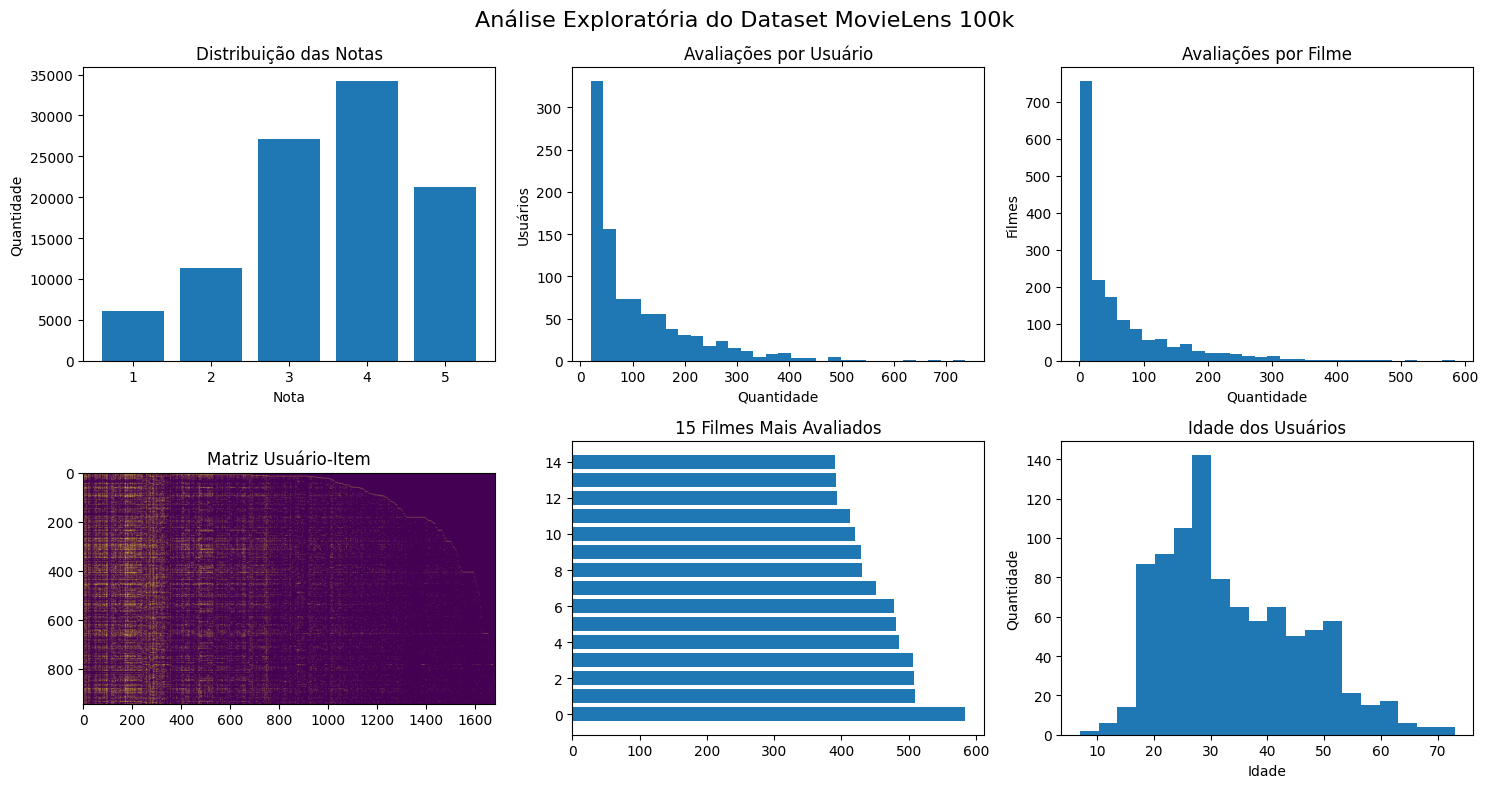

In [7]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

fig.suptitle("Análise Exploratória do Dataset MovieLens 100k", fontsize=16)

# Distribuição das notas
notas = ratings["rating"].value_counts().sort_index()

ax[0, 0].bar(notas.index, notas.values)
ax[0, 0].set_title("Distribuição das Notas")
ax[0, 0].set_xlabel("Nota")
ax[0, 0].set_ylabel("Quantidade")

# Avaliações por usuário
aval_por_usuario = ratings.groupby("user_id").size()

ax[0, 1].hist(aval_por_usuario, bins=30)
ax[0, 1].set_title("Avaliações por Usuário")
ax[0, 1].set_xlabel("Quantidade")
ax[0, 1].set_ylabel("Usuários")

# Avaliações por filme
aval_por_filme = ratings.groupby("item_id").size()

ax[0, 2].hist(aval_por_filme, bins=30)
ax[0, 2].set_title("Avaliações por Filme")
ax[0, 2].set_xlabel("Quantidade")
ax[0, 2].set_ylabel("Filmes")

# Matriz usuário-item
ax[1, 0].imshow(user_item_matrix.notna())
ax[1, 0].set_title("Matriz Usuário-Item")

# Top 15 filmes mais avaliados
top_filmes = ratings.groupby("item_id").size().sort_values(ascending=False).head(15)

ax[1, 1].barh(range(15), top_filmes.values)
ax[1, 1].set_title("15 Filmes Mais Avaliados")

# Idades dos usuários
ax[1, 2].hist(users["age"], bins=20)
ax[1, 2].set_title("Idade dos Usuários")
ax[1, 2].set_xlabel("Idade")
ax[1, 2].set_ylabel("Quantidade")

plt.tight_layout()
plt.show()

### Estatística

In [13]:
ratings_per_user = ratings.groupby("user_id").size()
ratings_per_item = ratings.groupby("item_id").size()

print("Distribuição das notas")
print(ratings["rating"].value_counts().sort_index())

print("\nUsuários")
print("Gênero:", users["gender"].value_counts().to_dict())
print("Ocupações diferentes:", users["occupation"].nunique())
print(f"Idade média: {users['age'].mean():.1f} anos")

print("\nAtividade")
print(f"Usuário mais ativo: {ratings_per_user.max()} avaliações")
print(f"Filme mais avaliado: {ratings_per_item.max()} avaliações")
print(f"Usuário mediano: {ratings_per_user.median():.0f} avaliações")

Distribuição das notas
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64

Usuários
Gênero: {'M': 670, 'F': 273}
Ocupações diferentes: 21
Idade média: 34.1 anos

Atividade
Usuário mais ativo: 737 avaliações
Filme mais avaliado: 583 avaliações
Usuário mediano: 65 avaliações


### Salvando dados

In [14]:
ratings.to_csv("ratings_clean.csv", index=False)
user_item_matrix.to_csv("user_item_matrix.csv")

## Metodologia de validação

### Carregando dados

In [15]:
ratings = pd.read_csv("ratings_clean.csv")

ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


### Validação

In [16]:
def kfold_split(data, n_splits=5, shuffle=True, random_state=42):
    indices = np.arange(len(data))

    if shuffle:
        rng = np.random.default_rng(random_state)
        rng.shuffle(indices)

    folds = np.array_split(indices, n_splits)

    for k in range(n_splits):
        test_idx = folds[k]
        train_idx = np.concatenate([folds[i] for i in range(n_splits) if i != k])

        yield train_idx, test_idx


def kfold_dfs(data, n_splits=5, shuffle=True, random_state=42):
    indices = np.arange(len(data))

    if shuffle:
        rng = np.random.default_rng(random_state)
        rng.shuffle(indices)

    folds = np.array_split(indices, n_splits)

    for k in range(n_splits):
        test_idx = folds[k]
        train_idx = np.concatenate([folds[i] for i in range(n_splits) if i != k])

        train_df = data.iloc[train_idx].reset_index(drop=True)
        test_df = data.iloc[test_idx].reset_index(drop=True)

        yield train_df, test_df

### Métricas de avaliação

In [17]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


In [18]:

def coverage(n_predicted, n_total):
    if n_total == 0:
        return 0
    return n_predicted / n_total

def evaluate(y_true, y_pred):
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "N": len(y_true)
    }


## Mean-Centering

In [19]:
def create_centered_matrix(train_df, total_users, total_items):
    matrix_train = train_df.pivot(
        index="user_id",
        columns="item_id",
        values="rating"
    )

    matrix_train = matrix_train.reindex(
        index=range(1, total_users + 1),
        columns=range(1, total_items + 1)
    )

    user_means = matrix_train.mean(axis=1)

    matrix_centered = matrix_train.sub(user_means, axis=0)

    matrix_centered_filled = matrix_centered.fillna(0)

    return matrix_centered_filled, user_means


TOTAL_USERS = ratings['user_id'].nunique()
TOTAL_ITEMS = ratings['item_id'].nunique()

folds_data = []

for fold, (train_df, test_df) in enumerate(kfold_dfs(ratings, n_splits=5)):

    train_matrix_centered, train_user_means = create_centered_matrix(
        train_df, TOTAL_USERS, TOTAL_ITEMS
    )

    folds_data.append({
        'train_df': train_df,
        'train_matrix_centered': train_matrix_centered,
        'user_means': train_user_means,
        'test_df': test_df
    })

print(f"K-Fold concluído")

K-Fold concluído


## Baseline

In [20]:
def avaliar_baseline_kfold(folds_data):
    resultados = []
    for k, fold in enumerate(folds_data):
        media_global = fold['train_df']['rating'].mean()
        y_true = fold['test_df']['rating'].values
        y_pred = np.full(len(y_true), media_global)
        m = evaluate(y_true, y_pred)
        m['fold'] = k + 1
        resultados.append(m)
    return pd.DataFrame(resultados)


In [21]:
print("BASELINE — Média Global")
df_baseline = avaliar_baseline_kfold(folds_data)
for _, row in df_baseline.iterrows():
    print(f"  Fold {int(row['fold'])} | MAE: {row['MAE']:.4f} | RMSE: {row['RMSE']:.4f}")
print(f"  {'─'*38}")
print(f"  Média  | MAE: {df_baseline['MAE'].mean():.4f} | RMSE: {df_baseline['RMSE'].mean():.4f}")
print(f"  ±std   | MAE: {df_baseline['MAE'].std():.4f} | RMSE: {df_baseline['RMSE'].std():.4f}\n")

BASELINE — Média Global
  Fold 1 | MAE: 0.9444 | RMSE: 1.1239
  Fold 2 | MAE: 0.9414 | RMSE: 1.1215
  Fold 3 | MAE: 0.9414 | RMSE: 1.1232
  Fold 4 | MAE: 0.9456 | RMSE: 1.1266
  Fold 5 | MAE: 0.9507 | RMSE: 1.1331
  ──────────────────────────────────────
  Média  | MAE: 0.9447 | RMSE: 1.1257
  ±std   | MAE: 0.0038 | RMSE: 0.0046



## Based Memory

In [22]:
def computar_matriz_similaridade(matriz_centralizada):
    M = matriz_centralizada.values
    num = M @ M.T
    normas = np.linalg.norm(M, axis=1, keepdims=True)
    den = normas @ normas.T
    den[den == 0] = 1e-9
    sim = num / den
    np.fill_diagonal(sim, 0)
    return sim  # ndarray (n_users, n_users)


def computar_matriz_similaridade_itens(matriz_centralizada):
    M = matriz_centralizada.values.T
    num = M @ M.T
    normas = np.linalg.norm(M, axis=1, keepdims=True)
    den = normas @ normas.T
    den[den == 0] = 1e-9
    sim = num / den
    np.fill_diagonal(sim, 0)
    return sim  # ndarray (n_items, n_items)

### User based

In [23]:
def prever_lote_knn_user(test_df, matriz_centralizada, medias_usuarios,
                          sim_matrix, k=20):


    user_index = {uid: idx for idx, uid in enumerate(matriz_centralizada.index)}
    item_index = {iid: idx for idx, iid in enumerate(matriz_centralizada.columns)}

    M = matriz_centralizada.values          # (n_users, n_items)
    means = medias_usuarios.values          # (n_users,)
    mean_index = {uid: idx for idx, uid in enumerate(medias_usuarios.index)}

    usuarios = test_df['user_id'].values.astype(int)
    itens    = test_df['item_id'].values.astype(int)
    n        = len(test_df)
    preds    = np.zeros(n)

    # média global para usuários/itens fora da matriz
    media_global = means.mean()

    for n_idx in range(n):
        u = usuarios[n_idx]
        i = itens[n_idx]

        u_pos = user_index.get(u, None)
        i_pos = item_index.get(i, None)

        if u_pos is None or i_pos is None:
            preds[n_idx] = media_global
            continue

        col_i = M[:, i_pos]

        # Só vizinhos que avaliaram o item
        avaliaram = col_i != 0

        if not avaliaram.any():
            preds[n_idx] = means[u_pos] if u_pos < len(means) else media_global
            continue

        # Similaridades do usuário alvo com quem avaliou o item
        sims_u = sim_matrix[u_pos]
        sims_validas = sims_u * avaliaram
        sims_validas[u_pos] = 0

        # Top-K por similaridade
        if sims_validas.max() <= 0:
            preds[n_idx] = means[u_pos] if u_pos < len(means) else media_global
            continue

        top_k_idx = np.argpartition(sims_validas, -k)[-k:]
        top_k_idx = top_k_idx[sims_validas[top_k_idx] > 0]

        if len(top_k_idx) == 0:
            preds[n_idx] = means[u_pos] if u_pos < len(means) else media_global
            continue

        top_sims  = sims_validas[top_k_idx]
        top_notas = col_i[top_k_idx]

        soma_pond = top_sims @ top_notas
        soma_sim  = top_sims.sum()

        mu_u = means[u_pos] if u_pos < len(means) else media_global
        pred = mu_u + soma_pond / soma_sim
        preds[n_idx] = np.clip(pred, 1.0, 5.0)

    return preds

In [24]:
def avaliar_knn_user(folds_data, k=20):
    resultados = []
    for fold_num, fold in enumerate(folds_data):
        matriz = fold['train_matrix_centered']
        medias = fold['user_means']
        test_df = fold['test_df']

        t0 = time.time()
        sim_matrix = computar_matriz_similaridade(matriz)
        preds = prever_lote_knn_user(test_df, matriz, medias, sim_matrix, k=k)
        y_true = test_df['rating'].values
        m = evaluate(y_true, preds)
        m['fold'] = fold_num + 1
        resultados.append(m)
        print(f"    Fold {fold_num+1} | MAE: {m['MAE']:.4f} | "
              f"RMSE: {m['RMSE']:.4f} | {time.time()-t0:.1f}s")
    return pd.DataFrame(resultados)

### Item based

In [25]:
def prever_lote_knn_item(test_df, matriz_centralizada, medias_usuarios,
                          sim_matrix_itens, k=20):

    user_index = {uid: idx for idx, uid in enumerate(matriz_centralizada.index)}
    item_index = {iid: idx for idx, iid in enumerate(matriz_centralizada.columns)}

    M = matriz_centralizada.values          # (n_users, n_items)
    means = medias_usuarios.values
    media_global = means.mean()

    usuarios = test_df['user_id'].values.astype(int)
    itens    = test_df['item_id'].values.astype(int)
    n        = len(test_df)
    preds    = np.zeros(n)

    for n_idx in range(n):
        u = usuarios[n_idx]
        i = itens[n_idx]

        u_pos = user_index.get(u, None)
        i_pos = item_index.get(i, None)

        if u_pos is None or i_pos is None:
            preds[n_idx] = media_global
            continue

        # Linha do usuário na matriz centralizada
        linha_u = M[u_pos]
        avaliou = linha_u != 0

        if not avaliou.any():
            preds[n_idx] = means[u_pos] if u_pos < len(means) else media_global
            continue

        # Similaridades do item alvo com os itens avaliados por u
        sims_i = sim_matrix_itens[i_pos]
        sims_validas = sims_i * avaliou
        sims_validas[i_pos] = 0

        if sims_validas.max() <= 0:
            preds[n_idx] = means[u_pos] if u_pos < len(means) else media_global
            continue

        top_k_idx = np.argpartition(sims_validas, -k)[-k:]
        top_k_idx = top_k_idx[sims_validas[top_k_idx] > 0]

        if len(top_k_idx) == 0:
            preds[n_idx] = means[u_pos] if u_pos < len(means) else media_global
            continue

        top_sims  = sims_validas[top_k_idx]
        top_notas = linha_u[top_k_idx]

        soma_pond = top_sims @ top_notas
        soma_sim  = top_sims.sum()

        mu_u = means[u_pos] if u_pos < len(means) else media_global
        pred = mu_u + soma_pond / soma_sim
        preds[n_idx] = np.clip(pred, 1.0, 5.0)

    return preds


In [26]:
def avaliar_knn_item(folds_data, k=20):
    resultados = []
    for fold_num, fold in enumerate(folds_data):
        matriz = fold['train_matrix_centered']
        medias = fold['user_means']
        test_df = fold['test_df']

        t0 = time.time()
        sim_matrix_itens = computar_matriz_similaridade_itens(matriz)
        preds = prever_lote_knn_item(test_df, matriz, medias, sim_matrix_itens, k=k)
        y_true = test_df['rating'].values
        m = evaluate(y_true, preds)
        m['fold'] = fold_num + 1
        resultados.append(m)
        print(f"    Fold {fold_num+1} | MAE: {m['MAE']:.4f} | "
              f"RMSE: {m['RMSE']:.4f} | {time.time()-t0:.1f}s")
    return pd.DataFrame(resultados)

Hiperparametrização KNN

In [27]:
folds_busca = folds_data[:3]
folds_final = folds_data

K_VALORES = [5, 10, 20, 30, 50]

# KNN User-Based
print("KNN USER-BASED — Busca de K")
hiper_user = []
for k_val in K_VALORES:
    print(f"\nK = {k_val}")
    df_k = avaliar_knn_user(folds_busca, k=k_val)
    hiper_user.append({
        'K': k_val,
        'MAE': df_k['MAE'].mean(),
        'RMSE': df_k['RMSE'].mean(),
        'MAE_std': df_k['MAE'].std(),
        'RMSE_std': df_k['RMSE'].std(),
    })

df_hiper_user = pd.DataFrame(hiper_user)
melhor_k_user = int(df_hiper_user.loc[df_hiper_user['RMSE'].idxmin(), 'K'])
print(f"\nMelhor K (user-based): {melhor_k_user}")

# KNN Item-Based
print("KNN ITEM-BASED")
hiper_item = []
for k_val in K_VALORES:
    print(f"\n  K = {k_val}")
    df_k = avaliar_knn_item(folds_busca, k=k_val)
    hiper_item.append({
        'K': k_val,
        'MAE': df_k['MAE'].mean(),
        'RMSE': df_k['RMSE'].mean(),
        'MAE_std': df_k['MAE'].std(),
        'RMSE_std': df_k['RMSE'].std(),
    })

df_hiper_item = pd.DataFrame(hiper_item)
melhor_k_item = int(df_hiper_item.loc[df_hiper_item['RMSE'].idxmin(), 'K'])
print(f"\nMelhor K (item-based): {melhor_k_item}")

# Avaliação final KNN com 5 folds
print(f"\nAvaliação final KNN User-Based (K={melhor_k_user}, 5 folds):")
df_knn_user_final = avaliar_knn_user(folds_final, k=melhor_k_user)
print(f"MAE: {df_knn_user_final['MAE'].mean():.4f} ± {df_knn_user_final['MAE'].std():.4f}")
print(f"RMSE: {df_knn_user_final['RMSE'].mean():.4f} ± {df_knn_user_final['RMSE'].std():.4f}")

print(f"\nAvaliação final KNN Item-Based (K={melhor_k_item}, 5 folds):")
df_knn_item_final = avaliar_knn_item(folds_final, k=melhor_k_item)
print(f"MAE: {df_knn_item_final['MAE'].mean():.4f} ± {df_knn_item_final['MAE'].std():.4f}")
print(f"RMSE: {df_knn_item_final['RMSE'].mean():.4f} ± {df_knn_item_final['RMSE'].std():.4f}")

KNN USER-BASED — Busca de K

K = 5
    Fold 1 | MAE: 0.7580 | RMSE: 0.9751 | 2.5s
    Fold 2 | MAE: 0.7504 | RMSE: 0.9652 | 1.4s
    Fold 3 | MAE: 0.7567 | RMSE: 0.9717 | 1.4s

K = 10
    Fold 1 | MAE: 0.7347 | RMSE: 0.9456 | 1.5s
    Fold 2 | MAE: 0.7308 | RMSE: 0.9384 | 1.9s
    Fold 3 | MAE: 0.7362 | RMSE: 0.9443 | 2.3s

K = 20
    Fold 1 | MAE: 0.7258 | RMSE: 0.9328 | 1.4s
    Fold 2 | MAE: 0.7213 | RMSE: 0.9275 | 1.5s
    Fold 3 | MAE: 0.7283 | RMSE: 0.9339 | 1.5s

K = 30
    Fold 1 | MAE: 0.7261 | RMSE: 0.9316 | 1.5s
    Fold 2 | MAE: 0.7196 | RMSE: 0.9250 | 1.5s
    Fold 3 | MAE: 0.7264 | RMSE: 0.9314 | 2.0s

K = 50
    Fold 1 | MAE: 0.7262 | RMSE: 0.9308 | 2.3s
    Fold 2 | MAE: 0.7206 | RMSE: 0.9255 | 2.0s
    Fold 3 | MAE: 0.7275 | RMSE: 0.9321 | 1.5s

Melhor K (user-based): 30
KNN ITEM-BASED

  K = 5
    Fold 1 | MAE: 0.7425 | RMSE: 0.9626 | 2.5s
    Fold 2 | MAE: 0.7392 | RMSE: 0.9563 | 2.5s
    Fold 3 | MAE: 0.7449 | RMSE: 0.9661 | 2.5s

  K = 10
    Fold 1 | MAE: 0.7247 |

## Based Model

### SVD

In [ ]:
def treinar_svd(train_df, total_usuarios, total_filmes,
                num_fatores=20, taxa=0.005, reg=0.02, epocas=20,
                random_state=42):

    rng = np.random.default_rng(random_state)

    us = train_df['user_id'].values.astype(np.int32)
    it = train_df['item_id'].values.astype(np.int32)
    rs = train_df['rating'].values.astype(np.float32)
    mu = rs.mean()

    bu = np.zeros(total_usuarios + 1, dtype=np.float32)
    bi = np.zeros(total_filmes   + 1, dtype=np.float32)
    P  = rng.uniform(-0.1, 0.1, (total_usuarios + 1, num_fatores)).astype(np.float32)
    Q  = rng.uniform(-0.1, 0.1, (total_filmes   + 1, num_fatores)).astype(np.float32)

    historico = []

    for epoca in range(epocas):

        idx = rng.permutation(len(rs))
        us_e, it_e, rs_e = us[idx], it[idx], rs[idx]

        for n in range(len(us_e)):
            u, i, r = us_e[n], it_e[n], rs_e[n]
            err = r - (mu + bu[u] + bi[i] + P[u] @ Q[i])

            bu[u] += taxa * (err - reg * bu[u])
            bi[i] += taxa * (err - reg * bi[i])


            pu_old = P[u].copy()
            P[u]  += taxa * (err * Q[i]    - reg * P[u])
            Q[i]  += taxa * (err * pu_old  - reg * Q[i])

        # RMSE de treino vetorizado
        erros = rs - (mu + bu[us] + bi[it] + np.sum(P[us] * Q[it], axis=1))
        historico.append(float(np.sqrt(np.mean(erros ** 2))))

    return {'mu': mu, 'bu': bu, 'bi': bi, 'P': P, 'Q': Q}, historico


def prever_svd(test_df, memoria):
    mu, bu, bi, P, Q = (memoria['mu'], memoria['bu'], memoria['bi'],
                        memoria['P'], memoria['Q'])
    us = test_df['user_id'].values.astype(np.int32)
    it = test_df['item_id'].values.astype(np.int32)

    # Clipa IDs fora do range (cold start)
    us = np.clip(us, 0, len(bu) - 1)
    it = np.clip(it, 0, len(bi) - 1)

    preds = mu + bu[us] + bi[it] + np.sum(P[us] * Q[it], axis=1)
    return np.clip(preds, 1.0, 5.0)

In [ ]:
def avaliar_svd(folds_data, num_fatores=20, epocas=20, taxa=0.005, reg=0.02):
    resultados, historicos = [], []
    for fold_num, fold in enumerate(folds_data):
        t0 = time.time()
        mem, hist = treinar_svd(fold['train_df'], TOTAL_USERS, TOTAL_ITEMS,
                                num_fatores=num_fatores, taxa=taxa,
                                reg=reg, epocas=epocas)
        preds  = prever_svd(fold['test_df'], mem)
        y_true = fold['test_df']['rating'].values
        m = evaluate(y_true, preds)
        m['fold'] = fold_num + 1
        resultados.append(m)
        historicos.append(hist)
        print(f"    Fold {fold_num+1} | MAE: {m['MAE']:.4f} | "
              f"RMSE: {m['RMSE']:.4f} | {time.time()-t0:.1f}s")
    return pd.DataFrame(resultados), historicos

In [ ]:
folds_busca = folds_data[:3]
folds_final = folds_data

FATORES_VALORES = [5, 10, 20, 50, 100]

# SVD

print("SVD (3 folds)")
hiper_svd = []
for f in FATORES_VALORES:
    print(f"\nnum_fatores = {f}")
    df_f, _ = avaliar_svd(folds_busca, num_fatores=f, epocas=20)
    hiper_svd.append({'num_fatores': f,
                      'MAE': df_f['MAE'].mean(),
                      'RMSE': df_f['RMSE'].mean(),
                      'MAE_std': df_f['MAE'].std(),
                      'RMSE_std': df_f['RMSE'].std()})

df_hiper_svd  = pd.DataFrame(hiper_svd)
melhor_f_svd  = int(df_hiper_svd.loc[df_hiper_svd['RMSE'].idxmin(), 'num_fatores'])
print(f"\nMelhor num_fatores (SVD): {melhor_f_svd}")


# Avaliação final
print(f"\nAvaliação final SVD ({melhor_f_svd} fatores, 5 folds):")
df_svd_final, hist_svd = avaliar_svd(folds_final, num_fatores=melhor_f_svd, epocas=20)
print(f"MAE: {df_svd_final['MAE'].mean():.4f} ± {df_svd_final['MAE'].std():.4f}")
print(f"RMSE: {df_svd_final['RMSE'].mean():.4f} ± {df_svd_final['RMSE'].std():.4f}")

SVD (3 folds)

num_fatores = 5
    Fold 1 | MAE: 0.7376 | RMSE: 0.9351 | 32.1s
    Fold 2 | MAE: 0.7360 | RMSE: 0.9337 | 31.4s
    Fold 3 | MAE: 0.7427 | RMSE: 0.9398 | 32.0s

num_fatores = 10
    Fold 1 | MAE: 0.7346 | RMSE: 0.9318 | 30.6s
    Fold 2 | MAE: 0.7318 | RMSE: 0.9293 | 31.4s
    Fold 3 | MAE: 0.7392 | RMSE: 0.9357 | 31.4s

num_fatores = 20
    Fold 1 | MAE: 0.7323 | RMSE: 0.9291 | 31.1s
    Fold 2 | MAE: 0.7300 | RMSE: 0.9274 | 32.3s
    Fold 3 | MAE: 0.7372 | RMSE: 0.9335 | 31.1s

num_fatores = 50
    Fold 1 | MAE: 0.7279 | RMSE: 0.9235 | 32.6s
    Fold 2 | MAE: 0.7254 | RMSE: 0.9222 | 31.4s
    Fold 3 | MAE: 0.7319 | RMSE: 0.9277 | 32.7s

num_fatores = 100
    Fold 1 | MAE: 0.7273 | RMSE: 0.9223 | 32.0s
    Fold 2 | MAE: 0.7251 | RMSE: 0.9215 | 33.3s
    Fold 3 | MAE: 0.7312 | RMSE: 0.9265 | 32.6s

Melhor num_fatores (SVD): 100

Avaliação final SVD (100 fatores, 5 folds):
    Fold 1 | MAE: 0.7273 | RMSE: 0.9223 | 32.7s
    Fold 2 | MAE: 0.7251 | RMSE: 0.9215 | 33.3s
    

### SVD++

In [ ]:
def treinar_svdpp(train_df, total_usuarios, total_filmes,
                  num_fatores=20, taxa=0.007, reg=0.02, epocas=20,
                  random_state=42):

    rng = np.random.default_rng(random_state)

    us = train_df['user_id'].values.astype(np.int32)
    it = train_df['item_id'].values.astype(np.int32)
    rs = train_df['rating'].values.astype(np.float32)
    mu = rs.mean()

    bu = np.zeros(total_usuarios + 1, dtype=np.float32)
    bi = np.zeros(total_filmes   + 1, dtype=np.float32)
    P  = rng.uniform(-0.1, 0.1, (total_usuarios + 1, num_fatores)).astype(np.float32)
    Q  = rng.uniform(-0.1, 0.1, (total_filmes   + 1, num_fatores)).astype(np.float32)
    Y  = rng.uniform(-0.01, 0.01, (total_filmes  + 1, num_fatores)).astype(np.float32)

    Nu = [[] for _ in range(total_usuarios + 1)]
    user_ratings = [[] for _ in range(total_usuarios + 1)]

    for u, i, r in zip(us, it, rs):
        Nu[u].append(i)
        user_ratings[u].append((i, r))

    sqrt_Nu = np.array([1.0 / np.sqrt(max(len(Nu[u]), 1))
                        for u in range(total_usuarios + 1)], dtype=np.float32)

    historico = []

    # Agrupamento por Usuário
    for epoca in range(epocas):
        # Embaralha a ordem dos usuários em vez das notas
        usuarios_embaralhados = rng.permutation(total_usuarios + 1)

        for u in usuarios_embaralhados:
            avaliacoes = user_ratings[u]
            if not avaliacoes:
                continue

            itens_u = Nu[u]
            norm_u = sqrt_Nu[u]

            soma_y = np.sum(Y[itens_u], axis=0) * norm_u
            p_u_enr = P[u] + soma_y

            soma_erros_q = np.zeros(num_fatores, dtype=np.float32)

            for i, r in avaliacoes:
                err = r - (mu + bu[u] + bi[i] + np.dot(Q[i], p_u_enr))

                bu[u] += taxa * (err - reg * bu[u])
                bi[i] += taxa * (err - reg * bi[i])

                pu_old = P[u].copy()
                P[u]  += taxa * (err * Q[i] - reg * P[u])
                Q[i]  += taxa * (err * pu_old - reg * Q[i])

                soma_erros_q += err * Q[i]

            Y[itens_u] += taxa * (soma_erros_q * norm_u - (reg * len(avaliacoes)) * Y[itens_u])

        sample_idx = rng.choice(len(rs), size=min(1000, len(rs)), replace=False)
        us_s, it_s, rs_s = us[sample_idx], it[sample_idx], rs[sample_idx]

        soma_y_s = np.array([
            np.sum(Y[Nu[u]], axis=0) * sqrt_Nu[u] if Nu[u] else np.zeros(num_fatores)
            for u in us_s
        ], dtype=np.float32)

        preds_s = mu + bu[us_s] + bi[it_s] + np.sum(Q[it_s] * (P[us_s] + soma_y_s), axis=1)
        rmse_s  = float(np.sqrt(np.mean((rs_s - preds_s) ** 2)))
        historico.append(rmse_s)
        print(f"      época {epoca+1}/{epocas} | RMSE amostral: {rmse_s:.4f}")

    return {'mu': mu, 'bu': bu, 'bi': bi, 'P': P, 'Q': Q,
            'Y': Y, 'Nu': Nu, 'sqrt_Nu': sqrt_Nu}, historico


def prever_svdpp(test_df, memoria):
    mu, bu, bi = memoria['mu'], memoria['bu'], memoria['bi']
    P, Q, Y    = memoria['P'], memoria['Q'], memoria['Y']
    Nu, sqrt_Nu = memoria['Nu'], memoria['sqrt_Nu']
    num_fatores = P.shape[1]

    us = test_df['user_id'].values.astype(np.int32)
    it = test_df['item_id'].values.astype(np.int32)
    us = np.clip(us, 0, len(bu) - 1)
    it = np.clip(it, 0, len(bi) - 1)

    soma_y = np.array([
        np.sum(Y[Nu[u]], axis=0) * sqrt_Nu[u] if Nu[u] else np.zeros(num_fatores)
        for u in us
    ], dtype=np.float32)

    preds = mu + bu[us] + bi[it] + np.sum(Q[it] * (P[us] + soma_y), axis=1)
    return np.clip(preds, 1.0, 5.0)


def avaliar_svdpp(folds_data_slice, num_fatores=20, epocas=20, taxa=0.007, reg=0.02):
    resultados, historicos = [], []
    for fold_num, fold in enumerate(folds_data_slice):
        t0 = time.time()
        mem, hist = treinar_svdpp(fold['train_df'], TOTAL_USERS, TOTAL_ITEMS,
                                  num_fatores=num_fatores, taxa=taxa,
                                  reg=reg, epocas=epocas)
        preds  = prever_svdpp(fold['test_df'], mem)
        y_true = fold['test_df']['rating'].values
        m = evaluate(y_true, preds)
        m['fold'] = fold_num + 1
        resultados.append(m)
        historicos.append(hist)
        print(f"    Fold {fold_num+1} | MAE: {m['MAE']:.4f} | "
              f"RMSE: {m['RMSE']:.4f} | {time.time()-t0:.1f}s")
    return pd.DataFrame(resultados), historicos

In [ ]:
# EXECUÇÃO DO SVD++
folds_busca = folds_data[:3]
folds_final = folds_data

FATORES_VALORES = [5, 10, 20, 50, 100]

print("SVD++")

hiper_svdpp = []
for f in FATORES_VALORES:
    print(f"\nTestando num_fatores = {f}")
    df_f, _ = avaliar_svdpp(folds_busca, num_fatores=f, epocas=20)
    hiper_svdpp.append({'num_fatores': f,
                        'MAE': df_f['MAE'].mean(),
                        'RMSE': df_f['RMSE'].mean(),
                        'MAE_std': df_f['MAE'].std(),
                        'RMSE_std': df_f['RMSE'].std()})

df_hiper_svdpp = pd.DataFrame(hiper_svdpp)

melhor_f_svdpp = df_hiper_svdpp.sort_values('RMSE').iloc[0]['num_fatores']
melhor_f_svdpp = int(melhor_f_svdpp)
print(f"\nMelhor num_fatores encontrado para o SVD++: {melhor_f_svdpp}")

# Avaliação final com os 5 folds
print(f"\n  Avaliação final SVD++ ({melhor_f_svdpp} fatores, executando nos 5 folds completos):")
df_svdpp_final, hist_svdpp = avaliar_svdpp(folds_final, num_fatores=melhor_f_svdpp, epocas=20)

print(f"MAE: {df_svdpp_final['MAE'].mean():.4f} ± {df_svdpp_final['MAE'].std():.4f}")
print(f"RMSE: {df_svdpp_final['RMSE'].mean():.4f} ± {df_svdpp_final['RMSE'].std():.4f}")

SVD++

Testando num_fatores = 5
      época 1/20 | RMSE amostral: 0.9888
      época 2/20 | RMSE amostral: 0.9800
      época 3/20 | RMSE amostral: 0.9514
      época 4/20 | RMSE amostral: 0.9395
      época 5/20 | RMSE amostral: 0.9295
      época 6/20 | RMSE amostral: 0.8780
      época 7/20 | RMSE amostral: 0.9208
      época 8/20 | RMSE amostral: 0.9391
      época 9/20 | RMSE amostral: 0.9523
      época 10/20 | RMSE amostral: 0.9449
      época 11/20 | RMSE amostral: 0.9080
      época 12/20 | RMSE amostral: 0.8940
      época 13/20 | RMSE amostral: 0.9156
      época 14/20 | RMSE amostral: 0.9243
      época 15/20 | RMSE amostral: 0.8730
      época 16/20 | RMSE amostral: 0.8933
      época 17/20 | RMSE amostral: 0.8814
      época 18/20 | RMSE amostral: 0.8993
      época 19/20 | RMSE amostral: 0.8969
      época 20/20 | RMSE amostral: 0.8954
    Fold 1 | MAE: 0.7305 | RMSE: 0.9281 | 38.2s
      época 1/20 | RMSE amostral: 0.9583
      época 2/20 | RMSE amostral: 0.9889
      é

## Gráficos

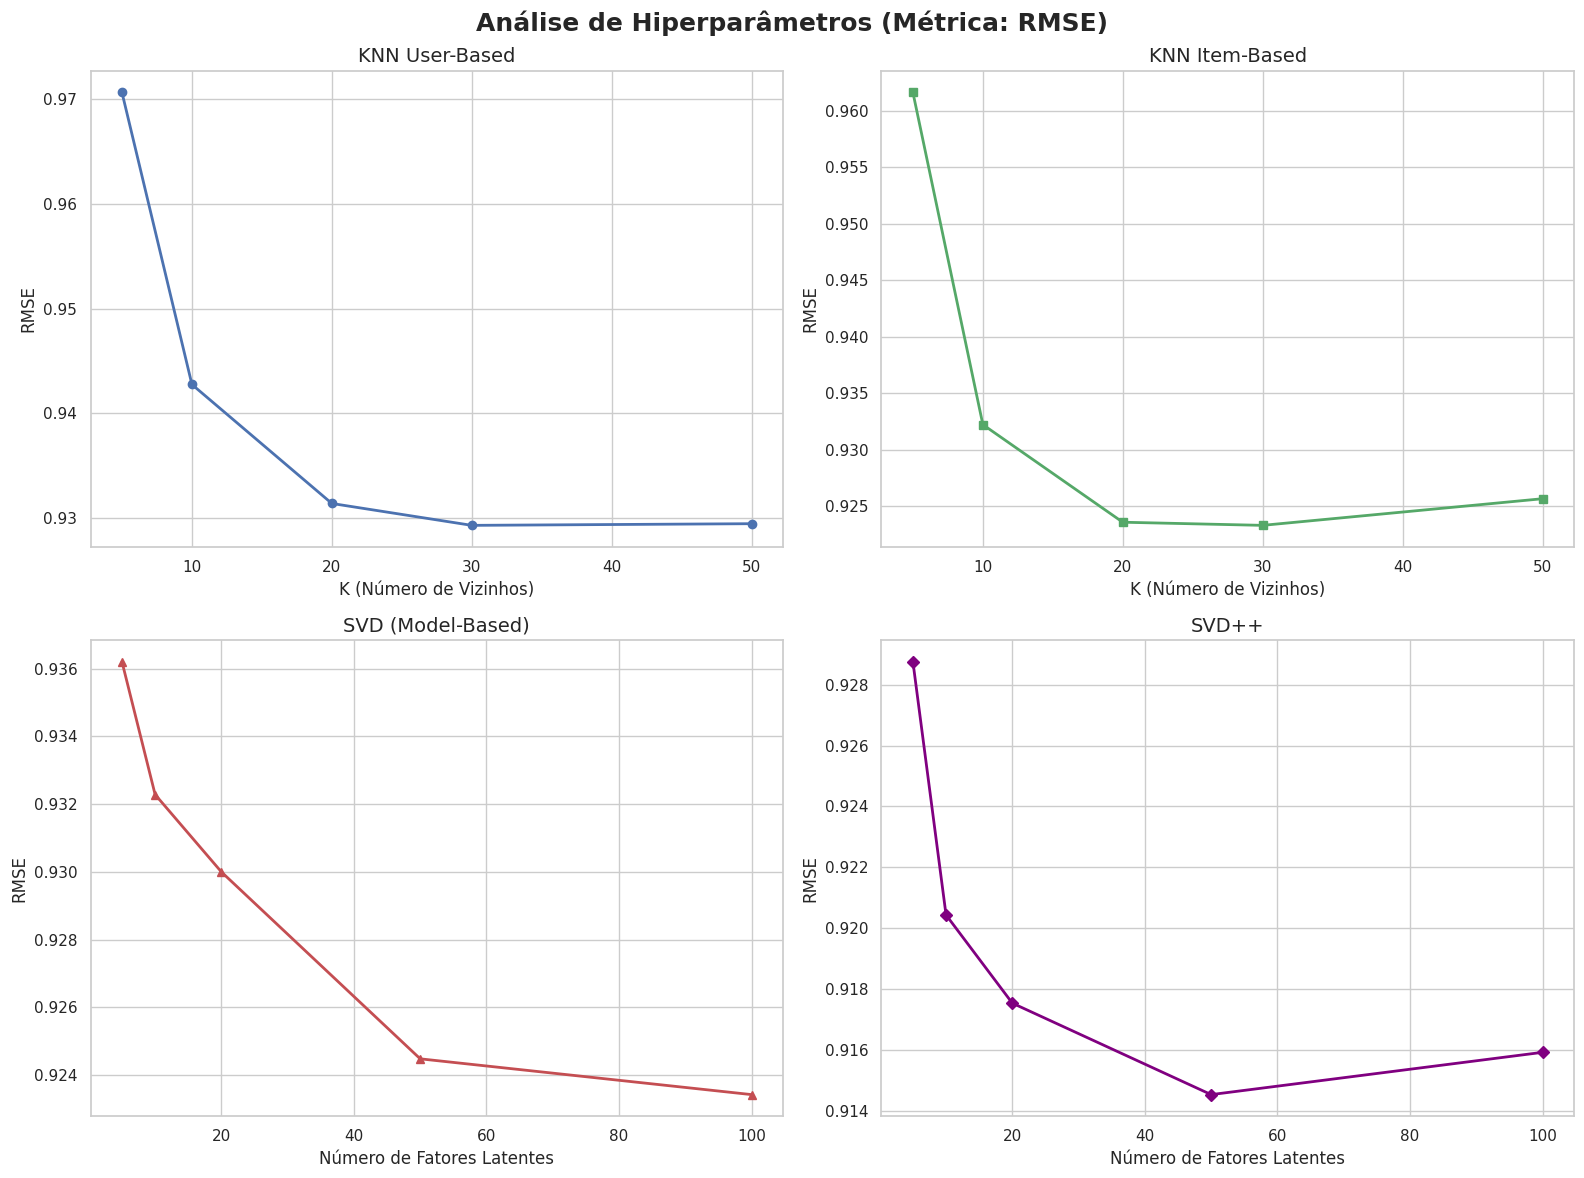

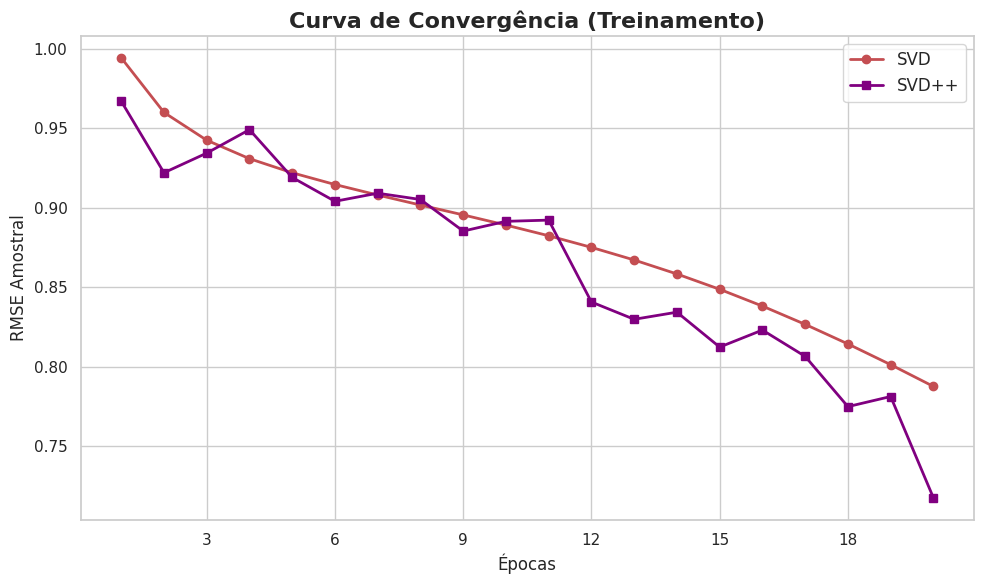

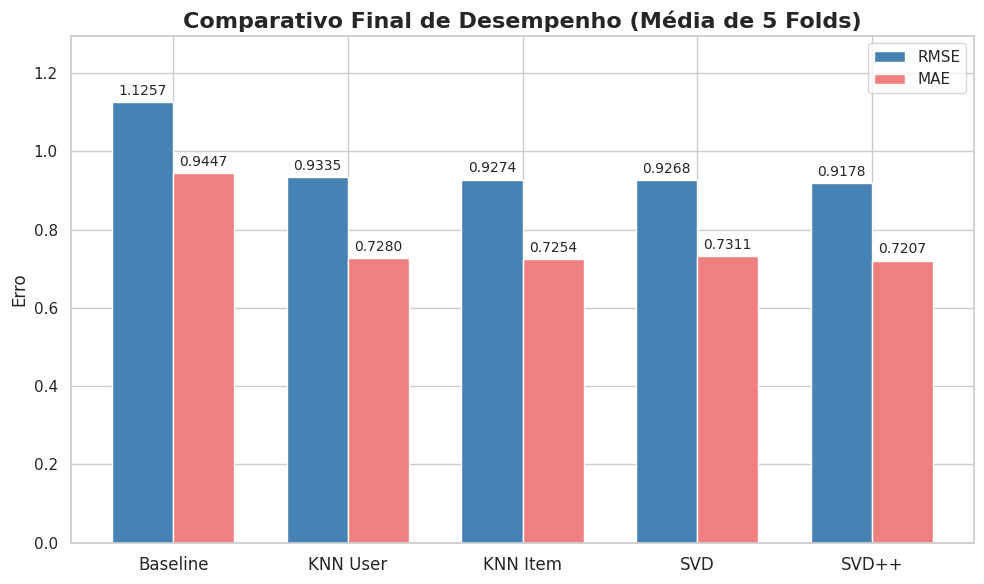

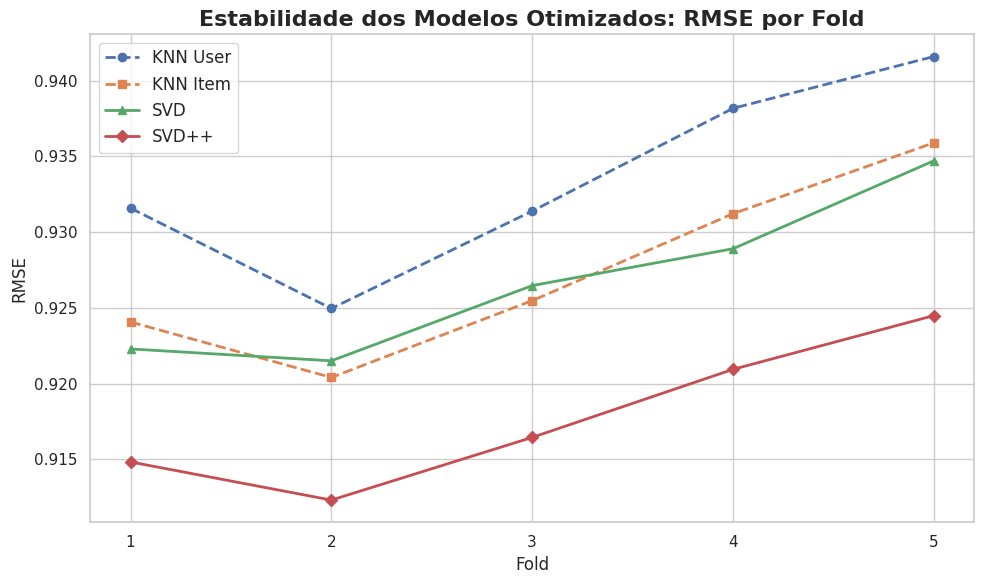

In [ ]:
sns.set_theme(style="whitegrid")

# 1. GRÁFICOS DE HIPERPARAMETRIZAÇÃO (K e Número de Fatores)
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
fig1.suptitle("Análise de Hiperparâmetros (Métrica: RMSE)", fontsize=18, fontweight='bold')

# KNN User-Based
axes1[0, 0].plot(df_hiper_user['K'], df_hiper_user['RMSE'], marker='o', color='b', linewidth=2)
axes1[0, 0].set_title('KNN User-Based', fontsize=14)
axes1[0, 0].set_xlabel('K (Número de Vizinhos)')
axes1[0, 0].set_ylabel('RMSE')

# KNN Item-Based
axes1[0, 1].plot(df_hiper_item['K'], df_hiper_item['RMSE'], marker='s', color='g', linewidth=2)
axes1[0, 1].set_title('KNN Item-Based', fontsize=14)
axes1[0, 1].set_xlabel('K (Número de Vizinhos)')
axes1[0, 1].set_ylabel('RMSE')

# SVD
axes1[1, 0].plot(df_hiper_svd['num_fatores'], df_hiper_svd['RMSE'], marker='^', color='r', linewidth=2)
axes1[1, 0].set_title('SVD (Model-Based)', fontsize=14)
axes1[1, 0].set_xlabel('Número de Fatores Latentes')
axes1[1, 0].set_ylabel('RMSE')

# SVD++
axes1[1, 1].plot(df_hiper_svdpp['num_fatores'], df_hiper_svdpp['RMSE'], marker='D', color='purple', linewidth=2)
axes1[1, 1].set_title('SVD++', fontsize=14)
axes1[1, 1].set_xlabel('Número de Fatores Latentes')
axes1[1, 1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()


# 2. GRÁFICOS DE CONVERGÊNCIA (SVD e SVD++)
mean_hist_svd = np.mean(hist_svd, axis=0)
mean_hist_svdpp = np.mean(hist_svdpp, axis=0)
epocas = range(1, len(mean_hist_svd) + 1)

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(epocas, mean_hist_svd, label='SVD', color='r', marker='o', linewidth=2)
ax2.plot(epocas, mean_hist_svdpp, label='SVD++', color='purple', marker='s', linewidth=2)

ax2.set_title("Curva de Convergência (Treinamento)", fontsize=16, fontweight='bold')
ax2.set_xlabel("Épocas")
ax2.set_ylabel("RMSE Amostral")
ax2.legend(fontsize=12)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()


# 3. GRÁFICO COMPARATIVO GERAL (MAE e RMSE)
modelos = ['Baseline', 'KNN User', 'KNN Item', 'SVD', 'SVD++']

rmses_finais = [
    df_baseline['RMSE'].mean(),
    df_knn_user_final['RMSE'].mean(),
    df_knn_item_final['RMSE'].mean(),
    df_svd_final['RMSE'].mean(),
    df_svdpp_final['RMSE'].mean()
]

maes_finais = [
    df_baseline['MAE'].mean(),
    df_knn_user_final['MAE'].mean(),
    df_knn_item_final['MAE'].mean(),
    df_svd_final['MAE'].mean(),
    df_svdpp_final['MAE'].mean()
]

x = np.arange(len(modelos))
width = 0.35

fig3, ax3 = plt.subplots(figsize=(10, 6))
rects1 = ax3.bar(x - width/2, rmses_finais, width, label='RMSE', color='steelblue')
rects2 = ax3.bar(x + width/2, maes_finais, width, label='MAE', color='lightcoral')

ax3.set_ylabel('Erro')
ax3.set_title('Comparativo Final de Desempenho (Média de 5 Folds)', fontsize=16, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(modelos, fontsize=12)
ax3.set_ylim(0, max(rmses_finais) * 1.15)
ax3.legend()


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax3.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()


# 4.1 GRÁFICO DE ESTABILIDADE FOCADO (Apenas Modelos Avançados)
folds = range(1, 6)

fig4_zoom, ax4_zoom = plt.subplots(figsize=(10, 6))

# Plotando apenas os modelos treinados
ax4_zoom.plot(folds, df_knn_user_final['RMSE'], marker='o', label='KNN User', linewidth=2, linestyle='--')
ax4_zoom.plot(folds, df_knn_item_final['RMSE'], marker='s', label='KNN Item', linewidth=2, linestyle='--')
ax4_zoom.plot(folds, df_svd_final['RMSE'], marker='^', label='SVD', linewidth=2)
ax4_zoom.plot(folds, df_svdpp_final['RMSE'], marker='D', label='SVD++', linewidth=2)

ax4_zoom.set_title('Estabilidade dos Modelos Otimizados: RMSE por Fold', fontsize=16, fontweight='bold')
ax4_zoom.set_xlabel('Fold')
ax4_zoom.set_ylabel('RMSE')
ax4_zoom.set_xticks(folds)

ax4_zoom.legend(fontsize=12, loc='best')

plt.tight_layout()
plt.show()

## Código completo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import random
import time

#!wget https://files.grouplens.org/datasets/movielens/ml-100k.zip
#!unzip -o ml-100k.zip

DATA_PATH = "ml-100k/"

# CARREGAMENTO DO DATASET MovieLens 100k

# Lendo as avaliações
ratings = pd.read_csv(
    DATA_PATH + "u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"],
    encoding="latin-1"
)

# Lendo os filmes
movies = pd.read_csv(
    DATA_PATH + "u.item",
    sep="|",
    names=["item_id", "title", "release_date", "video_release_date",
              "IMDb_URL"] + [f"genre_{i}" for i in range(19)],
    encoding="latin-1"
)

# Lendo os usuários
users = pd.read_csv(
    DATA_PATH + "u.user",
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip_code"],
    encoding="latin-1"
)


# Informações gerais sobre o dataset

print("Informações do Dataset MovieLens 100k\n\n")

print("Quantidade de avaliações:", f"{len(ratings):,}")
print("Quantidade de usuários:", f"{ratings['user_id'].nunique():,}")
print("Quantidade de filmes:", f"{ratings['item_id'].nunique():,}")
print("Menor nota:", ratings['rating'].min())
print("Maior nota:", ratings['rating'].max())
print("Média das notas:", ratings['rating'].mean())

esparsidade = 1 - (len(ratings) / (ratings['user_id'].nunique() * ratings['item_id'].nunique()))
print("Esparsidade:", round(esparsidade * 100, 2), "%")

# Matriz usuário-item

user_item_matrix = ratings.pivot(
    index="user_id",
    columns="item_id",
    values="rating"
)

print("Matriz Usuário-Item:")
print(f"{user_item_matrix.shape[0]:,}", "usuários x",
      f"{user_item_matrix.shape[1]:,}", "filmes")

preenchidos = user_item_matrix.notna().sum().sum()
total = user_item_matrix.size

print("Valores preenchidos:", f"{preenchidos:,}")
print("Total de posições:", f"{total:,}")

# Análise exploratória

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

fig.suptitle("Análise Exploratória do Dataset MovieLens 100k", fontsize=16)

# Distribuição das notas
notas = ratings["rating"].value_counts().sort_index()

ax[0, 0].bar(notas.index, notas.values)
ax[0, 0].set_title("Distribuição das Notas")
ax[0, 0].set_xlabel("Nota")
ax[0, 0].set_ylabel("Quantidade")

# Avaliações por usuário
aval_por_usuario = ratings.groupby("user_id").size()

ax[0, 1].hist(aval_por_usuario, bins=30)
ax[0, 1].set_title("Avaliações por Usuário")
ax[0, 1].set_xlabel("Quantidade")
ax[0, 1].set_ylabel("Usuários")

# Avaliações por filme
aval_por_filme = ratings.groupby("item_id").size()

ax[0, 2].hist(aval_por_filme, bins=30)
ax[0, 2].set_title("Avaliações por Filme")
ax[0, 2].set_xlabel("Quantidade")
ax[0, 2].set_ylabel("Filmes")

# Matriz usuário-item
ax[1, 0].imshow(user_item_matrix.notna())
ax[1, 0].set_title("Matriz Usuário-Item")

# Top 15 filmes mais avaliados
top_filmes = ratings.groupby("item_id").size().sort_values(ascending=False).head(15)

ax[1, 1].barh(range(15), top_filmes.values)
ax[1, 1].set_title("15 Filmes Mais Avaliados")

# Idades dos usuários
ax[1, 2].hist(users["age"], bins=20)
ax[1, 2].set_title("Idade dos Usuários")
ax[1, 2].set_xlabel("Idade")
ax[1, 2].set_ylabel("Quantidade")

plt.tight_layout()
plt.show()

# estatística

ratings_per_user = ratings.groupby("user_id").size()
ratings_per_item = ratings.groupby("item_id").size()

print("Distribuição das notas")
print(ratings["rating"].value_counts().sort_index())

print("\nUsuários")
print("Gênero:", users["gender"].value_counts().to_dict())
print("Ocupações diferentes:", users["occupation"].nunique())
print(f"Idade média: {users['age'].mean():.1f} anos")

print("\nAtividade")
print(f"Usuário mais ativo: {ratings_per_user.max()} avaliações")
print(f"Filme mais avaliado: {ratings_per_item.max()} avaliações")
print(f"Usuário mediano: {ratings_per_user.median():.0f} avaliações")

# Salvando dados
ratings.to_csv("ratings_clean.csv", index=False)
user_item_matrix.to_csv("user_item_matrix.csv")

# Validação

def kfold_split(data, n_splits=5, shuffle=True, random_state=42):
    indices = np.arange(len(data))

    if shuffle:
        rng = np.random.default_rng(random_state)
        rng.shuffle(indices)

    folds = np.array_split(indices, n_splits)

    for k in range(n_splits):
        test_idx = folds[k]
        train_idx = np.concatenate([folds[i] for i in range(n_splits) if i != k])

        yield train_idx, test_idx


def kfold_dfs(data, n_splits=5, shuffle=True, random_state=42):
    indices = np.arange(len(data))

    if shuffle:
        rng = np.random.default_rng(random_state)
        rng.shuffle(indices)

    folds = np.array_split(indices, n_splits)

    for k in range(n_splits):
        test_idx = folds[k]
        train_idx = np.concatenate([folds[i] for i in range(n_splits) if i != k])

        train_df = data.iloc[train_idx].reset_index(drop=True)
        test_df = data.iloc[test_idx].reset_index(drop=True)

        yield train_df, test_df

print("Fold definido")


# Definindo métricas de avaliação

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def coverage(n_predicted, n_total):
    if n_total == 0:
        return 0
    return n_predicted / n_total

def evaluate(y_true, y_pred):
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "N": len(y_true)
    }


print("Metricas definido")

# Mean-Centering

def create_centered_matrix(train_df, total_users, total_items):
    matrix_train = train_df.pivot(
        index="user_id",
        columns="item_id",
        values="rating"
    )

    matrix_train = matrix_train.reindex(
        index=range(1, total_users + 1),
        columns=range(1, total_items + 1)
    )

    user_means = matrix_train.mean(axis=1)

    matrix_centered = matrix_train.sub(user_means, axis=0)

    matrix_centered_filled = matrix_centered.fillna(0)

    return matrix_centered_filled, user_means


TOTAL_USERS = ratings['user_id'].nunique()
TOTAL_ITEMS = ratings['item_id'].nunique()

folds_data = []

for fold, (train_df, test_df) in enumerate(kfold_dfs(ratings, n_splits=5)):

    train_matrix_centered, train_user_means = create_centered_matrix(
        train_df, TOTAL_USERS, TOTAL_ITEMS
    )

    # O dicionário atualizado com o train_df salvo em segurança
    folds_data.append({
        'train_df': train_df,
        'train_matrix_centered': train_matrix_centered,
        'user_means': train_user_means,
        'test_df': test_df
    })


# Based memory

def computar_matriz_similaridade(matriz_centralizada):
    M = matriz_centralizada.values
    num = M @ M.T
    normas = np.linalg.norm(M, axis=1, keepdims=True)
    den = normas @ normas.T
    den[den == 0] = 1e-9
    sim = num / den
    np.fill_diagonal(sim, 0)
    return sim  # ndarray (n_users, n_users)


def computar_matriz_similaridade_itens(matriz_centralizada):
    M = matriz_centralizada.values.T
    num = M @ M.T
    normas = np.linalg.norm(M, axis=1, keepdims=True)
    den = normas @ normas.T
    den[den == 0] = 1e-9
    sim = num / den
    np.fill_diagonal(sim, 0)
    return sim  # ndarray (n_items, n_items)

###### User based ######

def prever_lote_knn_user(test_df, matriz_centralizada, medias_usuarios,
                          sim_matrix, k=20):


    user_index = {uid: idx for idx, uid in enumerate(matriz_centralizada.index)}
    item_index = {iid: idx for idx, iid in enumerate(matriz_centralizada.columns)}

    M = matriz_centralizada.values          # (n_users, n_items)
    means = medias_usuarios.values          # (n_users,)
    mean_index = {uid: idx for idx, uid in enumerate(medias_usuarios.index)}

    usuarios = test_df['user_id'].values.astype(int)
    itens    = test_df['item_id'].values.astype(int)
    n        = len(test_df)
    preds    = np.zeros(n)

    # média global para usuários/itens fora da matriz
    media_global = means.mean()

    for n_idx in range(n):
        u = usuarios[n_idx]
        i = itens[n_idx]

        u_pos = user_index.get(u, None)
        i_pos = item_index.get(i, None)

        if u_pos is None or i_pos is None:
            preds[n_idx] = media_global
            continue

        col_i = M[:, i_pos]

        # Só vizinhos que avaliaram o item
        avaliaram = col_i != 0

        if not avaliaram.any():
            preds[n_idx] = means[u_pos] if u_pos < len(means) else media_global
            continue

        # Similaridades do usuário alvo com quem avaliou o item
        sims_u = sim_matrix[u_pos]
        sims_validas = sims_u * avaliaram
        sims_validas[u_pos] = 0

        # Top-K por similaridade
        if sims_validas.max() <= 0:
            preds[n_idx] = means[u_pos] if u_pos < len(means) else media_global
            continue

        top_k_idx = np.argpartition(sims_validas, -k)[-k:]
        top_k_idx = top_k_idx[sims_validas[top_k_idx] > 0]

        if len(top_k_idx) == 0:
            preds[n_idx] = means[u_pos] if u_pos < len(means) else media_global
            continue

        top_sims  = sims_validas[top_k_idx]
        top_notas = col_i[top_k_idx]

        soma_pond = top_sims @ top_notas
        soma_sim  = top_sims.sum()

        mu_u = means[u_pos] if u_pos < len(means) else media_global
        pred = mu_u + soma_pond / soma_sim
        preds[n_idx] = np.clip(pred, 1.0, 5.0)

    return preds

def avaliar_knn_user(folds_data, k=20):
    resultados = []
    for fold_num, fold in enumerate(folds_data):
        matriz = fold['train_matrix_centered']
        medias = fold['user_means']
        test_df = fold['test_df']

        t0 = time.time()
        sim_matrix = computar_matriz_similaridade(matriz)
        preds = prever_lote_knn_user(test_df, matriz, medias, sim_matrix, k=k)
        y_true = test_df['rating'].values
        m = evaluate(y_true, preds)
        m['fold'] = fold_num + 1
        resultados.append(m)
        print(f"    Fold {fold_num+1} | MAE: {m['MAE']:.4f} | "
              f"RMSE: {m['RMSE']:.4f} | {time.time()-t0:.1f}s")
    return pd.DataFrame(resultados)

####### item based ##########

def prever_lote_knn_item(test_df, matriz_centralizada, medias_usuarios,
                          sim_matrix_itens, k=20):

    user_index = {uid: idx for idx, uid in enumerate(matriz_centralizada.index)}
    item_index = {iid: idx for idx, iid in enumerate(matriz_centralizada.columns)}

    M = matriz_centralizada.values          # (n_users, n_items)
    means = medias_usuarios.values
    media_global = means.mean()

    usuarios = test_df['user_id'].values.astype(int)
    itens    = test_df['item_id'].values.astype(int)
    n        = len(test_df)
    preds    = np.zeros(n)

    for n_idx in range(n):
        u = usuarios[n_idx]
        i = itens[n_idx]

        u_pos = user_index.get(u, None)
        i_pos = item_index.get(i, None)

        if u_pos is None or i_pos is None:
            preds[n_idx] = media_global
            continue

        # Linha do usuário na matriz centralizada
        linha_u = M[u_pos]
        avaliou = linha_u != 0

        if not avaliou.any():
            preds[n_idx] = means[u_pos] if u_pos < len(means) else media_global
            continue

        # Similaridades do item alvo com os itens avaliados por u
        sims_i = sim_matrix_itens[i_pos]
        sims_validas = sims_i * avaliou
        sims_validas[i_pos] = 0

        if sims_validas.max() <= 0:
            preds[n_idx] = means[u_pos] if u_pos < len(means) else media_global
            continue

        top_k_idx = np.argpartition(sims_validas, -k)[-k:]
        top_k_idx = top_k_idx[sims_validas[top_k_idx] > 0]

        if len(top_k_idx) == 0:
            preds[n_idx] = means[u_pos] if u_pos < len(means) else media_global
            continue

        top_sims  = sims_validas[top_k_idx]
        top_notas = linha_u[top_k_idx]

        soma_pond = top_sims @ top_notas
        soma_sim  = top_sims.sum()

        mu_u = means[u_pos] if u_pos < len(means) else media_global
        pred = mu_u + soma_pond / soma_sim
        preds[n_idx] = np.clip(pred, 1.0, 5.0)

    return preds


def avaliar_knn_item(folds_data, k=20):
    resultados = []
    for fold_num, fold in enumerate(folds_data):
        matriz = fold['train_matrix_centered']
        medias = fold['user_means']
        test_df = fold['test_df']

        t0 = time.time()
        sim_matrix_itens = computar_matriz_similaridade_itens(matriz)
        preds = prever_lote_knn_item(test_df, matriz, medias, sim_matrix_itens, k=k)
        y_true = test_df['rating'].values
        m = evaluate(y_true, preds)
        m['fold'] = fold_num + 1
        resultados.append(m)
        print(f"    Fold {fold_num+1} | MAE: {m['MAE']:.4f} | "
              f"RMSE: {m['RMSE']:.4f} | {time.time()-t0:.1f}s")
    return pd.DataFrame(resultados)


  ########### hiperparametrização ##########

folds_busca = folds_data[:3]
folds_final = folds_data

K_VALORES = [5, 10, 20, 30, 50]

# KNN User-Based
print("KNN USER-BASED — Busca de K")
hiper_user = []
for k_val in K_VALORES:
    print(f"\nK = {k_val}")
    df_k = avaliar_knn_user(folds_busca, k=k_val)
    hiper_user.append({
        'K': k_val,
        'MAE': df_k['MAE'].mean(),
        'RMSE': df_k['RMSE'].mean(),
        'MAE_std': df_k['MAE'].std(),
        'RMSE_std': df_k['RMSE'].std(),
    })

df_hiper_user = pd.DataFrame(hiper_user)
melhor_k_user = int(df_hiper_user.loc[df_hiper_user['RMSE'].idxmin(), 'K'])
print(f"\nMelhor K (user-based): {melhor_k_user}")

# KNN Item-Based
print("KNN ITEM-BASED")
hiper_item = []
for k_val in K_VALORES:
    print(f"\n  K = {k_val}")
    df_k = avaliar_knn_item(folds_busca, k=k_val)
    hiper_item.append({
        'K': k_val,
        'MAE': df_k['MAE'].mean(),
        'RMSE': df_k['RMSE'].mean(),
        'MAE_std': df_k['MAE'].std(),
        'RMSE_std': df_k['RMSE'].std(),
    })

df_hiper_item = pd.DataFrame(hiper_item)
melhor_k_item = int(df_hiper_item.loc[df_hiper_item['RMSE'].idxmin(), 'K'])
print(f"\nMelhor K (item-based): {melhor_k_item}")

# Avaliação final KNN com 5 folds
print(f"\nAvaliação final KNN User-Based (K={melhor_k_user}, 5 folds):")
df_knn_user_final = avaliar_knn_user(folds_final, k=melhor_k_user)
print(f"MAE: {df_knn_user_final['MAE'].mean():.4f} ± {df_knn_user_final['MAE'].std():.4f}")
print(f"RMSE: {df_knn_user_final['RMSE'].mean():.4f} ± {df_knn_user_final['RMSE'].std():.4f}")

print(f"\nAvaliação final KNN Item-Based (K={melhor_k_item}, 5 folds):")
df_knn_item_final = avaliar_knn_item(folds_final, k=melhor_k_item)
print(f"MAE: {df_knn_item_final['MAE'].mean():.4f} ± {df_knn_item_final['MAE'].std():.4f}")
print(f"RMSE: {df_knn_item_final['RMSE'].mean():.4f} ± {df_knn_item_final['RMSE'].std():.4f}")


# Model based


# SVD

def treinar_svd(train_df, total_usuarios, total_filmes,
                num_fatores=20, taxa=0.005, reg=0.02, epocas=20,
                random_state=42):

    rng = np.random.default_rng(random_state)

    us = train_df['user_id'].values.astype(np.int32)
    it = train_df['item_id'].values.astype(np.int32)
    rs = train_df['rating'].values.astype(np.float32)
    mu = rs.mean()

    bu = np.zeros(total_usuarios + 1, dtype=np.float32)
    bi = np.zeros(total_filmes   + 1, dtype=np.float32)
    P  = rng.uniform(-0.1, 0.1, (total_usuarios + 1, num_fatores)).astype(np.float32)
    Q  = rng.uniform(-0.1, 0.1, (total_filmes   + 1, num_fatores)).astype(np.float32)

    historico = []

    for epoca in range(epocas):

        idx = rng.permutation(len(rs))
        us_e, it_e, rs_e = us[idx], it[idx], rs[idx]

        for n in range(len(us_e)):
            u, i, r = us_e[n], it_e[n], rs_e[n]
            err = r - (mu + bu[u] + bi[i] + P[u] @ Q[i])

            bu[u] += taxa * (err - reg * bu[u])
            bi[i] += taxa * (err - reg * bi[i])


            pu_old = P[u].copy()
            P[u]  += taxa * (err * Q[i]    - reg * P[u])
            Q[i]  += taxa * (err * pu_old  - reg * Q[i])

        # RMSE de treino vetorizado
        erros = rs - (mu + bu[us] + bi[it] + np.sum(P[us] * Q[it], axis=1))
        historico.append(float(np.sqrt(np.mean(erros ** 2))))

    return {'mu': mu, 'bu': bu, 'bi': bi, 'P': P, 'Q': Q}, historico


def prever_svd(test_df, memoria):
    mu, bu, bi, P, Q = (memoria['mu'], memoria['bu'], memoria['bi'],
                        memoria['P'], memoria['Q'])
    us = test_df['user_id'].values.astype(np.int32)
    it = test_df['item_id'].values.astype(np.int32)

    # Clipa IDs fora do range (cold start)
    us = np.clip(us, 0, len(bu) - 1)
    it = np.clip(it, 0, len(bi) - 1)

    preds = mu + bu[us] + bi[it] + np.sum(P[us] * Q[it], axis=1)
    return np.clip(preds, 1.0, 5.0)


def avaliar_svd(folds_data, num_fatores=20, epocas=20, taxa=0.005, reg=0.02):
    resultados, historicos = [], []
    for fold_num, fold in enumerate(folds_data):
        t0 = time.time()
        mem, hist = treinar_svd(fold['train_df'], TOTAL_USERS, TOTAL_ITEMS,
                                num_fatores=num_fatores, taxa=taxa,
                                reg=reg, epocas=epocas)
        preds  = prever_svd(fold['test_df'], mem)
        y_true = fold['test_df']['rating'].values
        m = evaluate(y_true, preds)
        m['fold'] = fold_num + 1
        resultados.append(m)
        historicos.append(hist)
        print(f"    Fold {fold_num+1} | MAE: {m['MAE']:.4f} | "
              f"RMSE: {m['RMSE']:.4f} | {time.time()-t0:.1f}s")
    return pd.DataFrame(resultados), historicos


folds_busca = folds_data[:3]
folds_final = folds_data

FATORES_VALORES = [5, 10, 20, 50, 100]

# SVD

print("SVD (3 folds)")
hiper_svd = []
for f in FATORES_VALORES:
    print(f"\nnum_fatores = {f}")
    df_f, _ = avaliar_svd(folds_busca, num_fatores=f, epocas=20)
    hiper_svd.append({'num_fatores': f,
                      'MAE': df_f['MAE'].mean(),
                      'RMSE': df_f['RMSE'].mean(),
                      'MAE_std': df_f['MAE'].std(),
                      'RMSE_std': df_f['RMSE'].std()})

df_hiper_svd  = pd.DataFrame(hiper_svd)
melhor_f_svd  = int(df_hiper_svd.loc[df_hiper_svd['RMSE'].idxmin(), 'num_fatores'])
print(f"\nMelhor num_fatores (SVD): {melhor_f_svd}")


# Avaliação final
print(f"\nAvaliação final SVD ({melhor_f_svd} fatores, 5 folds):")
df_svd_final, hist_svd = avaliar_svd(folds_final, num_fatores=melhor_f_svd, epocas=20)
print(f"MAE: {df_svd_final['MAE'].mean():.4f} ± {df_svd_final['MAE'].std():.4f}")
print(f"RMSE: {df_svd_final['RMSE'].mean():.4f} ± {df_svd_final['RMSE'].std():.4f}")



###############################SVD++################################3



def treinar_svdpp(train_df, total_usuarios, total_filmes,
                  num_fatores=20, taxa=0.007, reg=0.02, epocas=20,
                  random_state=42):

    rng = np.random.default_rng(random_state)

    us = train_df['user_id'].values.astype(np.int32)
    it = train_df['item_id'].values.astype(np.int32)
    rs = train_df['rating'].values.astype(np.float32)
    mu = rs.mean()

    bu = np.zeros(total_usuarios + 1, dtype=np.float32)
    bi = np.zeros(total_filmes   + 1, dtype=np.float32)
    P  = rng.uniform(-0.1, 0.1, (total_usuarios + 1, num_fatores)).astype(np.float32)
    Q  = rng.uniform(-0.1, 0.1, (total_filmes   + 1, num_fatores)).astype(np.float32)
    Y  = rng.uniform(-0.01, 0.01, (total_filmes  + 1, num_fatores)).astype(np.float32)

    # OTIMIZAÇÃO 1: Pré-agrupar os itens e as notas por usuário
    # Isso evita ter que buscar as notas na lista gigante durante o treino
    Nu = [[] for _ in range(total_usuarios + 1)]
    user_ratings = [[] for _ in range(total_usuarios + 1)]

    for u, i, r in zip(us, it, rs):
        Nu[u].append(i)
        user_ratings[u].append((i, r))

    sqrt_Nu = np.array([1.0 / np.sqrt(max(len(Nu[u]), 1))
                        for u in range(total_usuarios + 1)], dtype=np.float32)

    historico = []

    # ── Loop SGD Otimizado (Agrupamento por Usuário) ──────────────
    for epoca in range(epocas):
        # Embaralhamos a ordem dos usuários em vez das notas
        usuarios_embaralhados = rng.permutation(total_usuarios + 1)

        for u in usuarios_embaralhados:
            avaliacoes = user_ratings[u]
            if not avaliacoes:
                continue # Pula se o usuário não tiver avaliações no treino

            itens_u = Nu[u]
            norm_u = sqrt_Nu[u]

            # OTIMIZAÇÃO 2: Calcula soma_y UMA ÚNICA VEZ para o usuário
            soma_y = np.sum(Y[itens_u], axis=0) * norm_u
            p_u_enr = P[u] + soma_y

            # Variável para acumular os erros e atualizar o Y apenas uma vez no final
            soma_erros_q = np.zeros(num_fatores, dtype=np.float32)

            # Iteramos pelas avaliações desse usuário específico
            for i, r in avaliacoes:
                err = r - (mu + bu[u] + bi[i] + np.dot(Q[i], p_u_enr))

                # Atualiza os vieses e fatores (P e Q) na hora
                bu[u] += taxa * (err - reg * bu[u])
                bi[i] += taxa * (err - reg * bi[i])

                pu_old = P[u].copy()
                P[u]  += taxa * (err * Q[i] - reg * P[u])
                Q[i]  += taxa * (err * pu_old - reg * Q[i])

                # Acumula a atualização para a matriz Y
                soma_erros_q += err * Q[i]

            # OTIMIZAÇÃO 3: Atualiza a matriz Y de todos os itens do usuário de uma só vez
            # Multiplicamos o 'reg' pelo tamanho de avaliações para manter o peso matemático da regularização
            Y[itens_u] += taxa * (soma_erros_q * norm_u - (reg * len(avaliacoes)) * Y[itens_u])

        # RMSE amostral rápido ao final da época (inalterado)
        sample_idx = rng.choice(len(rs), size=min(1000, len(rs)), replace=False)
        us_s, it_s, rs_s = us[sample_idx], it[sample_idx], rs[sample_idx]

        soma_y_s = np.array([
            np.sum(Y[Nu[u]], axis=0) * sqrt_Nu[u] if Nu[u] else np.zeros(num_fatores)
            for u in us_s
        ], dtype=np.float32)

        preds_s = mu + bu[us_s] + bi[it_s] + np.sum(Q[it_s] * (P[us_s] + soma_y_s), axis=1)
        rmse_s  = float(np.sqrt(np.mean((rs_s - preds_s) ** 2)))
        historico.append(rmse_s)
        print(f"      época {epoca+1}/{epocas} | RMSE amostral: {rmse_s:.4f}")

    return {'mu': mu, 'bu': bu, 'bi': bi, 'P': P, 'Q': Q,
            'Y': Y, 'Nu': Nu, 'sqrt_Nu': sqrt_Nu}, historico


def prever_svdpp(test_df, memoria):
    mu, bu, bi = memoria['mu'], memoria['bu'], memoria['bi']
    P, Q, Y    = memoria['P'], memoria['Q'], memoria['Y']
    Nu, sqrt_Nu = memoria['Nu'], memoria['sqrt_Nu']
    num_fatores = P.shape[1]

    us = test_df['user_id'].values.astype(np.int32)
    it = test_df['item_id'].values.astype(np.int32)
    us = np.clip(us, 0, len(bu) - 1)
    it = np.clip(it, 0, len(bi) - 1)

    soma_y = np.array([
        np.sum(Y[Nu[u]], axis=0) * sqrt_Nu[u] if Nu[u] else np.zeros(num_fatores)
        for u in us
    ], dtype=np.float32)

    preds = mu + bu[us] + bi[it] + np.sum(Q[it] * (P[us] + soma_y), axis=1)
    return np.clip(preds, 1.0, 5.0)


def avaliar_svdpp(folds_data_slice, num_fatores=20, epocas=20, taxa=0.007, reg=0.02):
    resultados, historicos = [], []
    for fold_num, fold in enumerate(folds_data_slice):
        t0 = time.time()
        mem, hist = treinar_svdpp(fold['train_df'], TOTAL_USERS, TOTAL_ITEMS,
                                  num_fatores=num_fatores, taxa=taxa,
                                  reg=reg, epocas=epocas)
        preds  = prever_svdpp(fold['test_df'], mem)
        y_true = fold['test_df']['rating'].values
        m = evaluate(y_true, preds)
        m['fold'] = fold_num + 1
        resultados.append(m)
        historicos.append(hist)
        print(f"    Fold {fold_num+1} | MAE: {m['MAE']:.4f} | "
              f"RMSE: {m['RMSE']:.4f} | {time.time()-t0:.1f}s")
    return pd.DataFrame(resultados), historicos

# ==============================================================================
# EXECUÇÃO DO SVD++
# ==============================================================================

# CORREÇÃO: Definir quem é o fold de busca ANTES de iniciar a hiperparametrização
folds_busca = folds_data[:3]
folds_final = folds_data

FATORES_VALORES = [5, 10, 20, 50, 100]

print("\n" + "=" * 52)
print("SVD++ — Busca de num_fatores (usando apenas 3 folds para ser mais rápido)")
print("=" * 52)

hiper_svdpp = []
for f in FATORES_VALORES:
    print(f"\n  Testando num_fatores = {f}")
    df_f, _ = avaliar_svdpp(folds_busca, num_fatores=f, epocas=20)
    hiper_svdpp.append({'num_fatores': f,
                        'MAE':      df_f['MAE'].mean(),
                        'RMSE':     df_f['RMSE'].mean(),
                        'MAE_std':  df_f['MAE'].std(),
                        'RMSE_std': df_f['RMSE'].std()})

df_hiper_svdpp = pd.DataFrame(hiper_svdpp)

# Logica simples de achar o menor para evitar idxmin
melhor_f_svdpp = df_hiper_svdpp.sort_values('RMSE').iloc[0]['num_fatores']
melhor_f_svdpp = int(melhor_f_svdpp)
print(f"\n  ✓ Melhor num_fatores encontrado para o SVD++: {melhor_f_svdpp}")

# ── Avaliação final com os 5 folds completos ───────────────────────────────
print(f"\n  Avaliação final SVD++ ({melhor_f_svdpp} fatores, executando nos 5 folds completos):")
df_svdpp_final, hist_svdpp = avaliar_svdpp(folds_final, num_fatores=melhor_f_svdpp, epocas=20)

print(f"  → MAE:  {df_svdpp_final['MAE'].mean():.4f} ± {df_svdpp_final['MAE'].std():.4f}")
print(f"  → RMSE: {df_svdpp_final['RMSE'].mean():.4f} ± {df_svdpp_final['RMSE'].std():.4f}")


#################Gráficos###################

sns.set_theme(style="whitegrid")

# 1. GRÁFICOS DE HIPERPARAMETRIZAÇÃO (K e Número de Fatores)
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
fig1.suptitle("Análise de Hiperparâmetros (Métrica: RMSE)", fontsize=18, fontweight='bold')

# KNN User-Based
axes1[0, 0].plot(df_hiper_user['K'], df_hiper_user['RMSE'], marker='o', color='b', linewidth=2)
axes1[0, 0].set_title('KNN User-Based', fontsize=14)
axes1[0, 0].set_xlabel('K (Número de Vizinhos)')
axes1[0, 0].set_ylabel('RMSE')

# KNN Item-Based
axes1[0, 1].plot(df_hiper_item['K'], df_hiper_item['RMSE'], marker='s', color='g', linewidth=2)
axes1[0, 1].set_title('KNN Item-Based', fontsize=14)
axes1[0, 1].set_xlabel('K (Número de Vizinhos)')
axes1[0, 1].set_ylabel('RMSE')

# SVD
axes1[1, 0].plot(df_hiper_svd['num_fatores'], df_hiper_svd['RMSE'], marker='^', color='r', linewidth=2)
axes1[1, 0].set_title('SVD (Model-Based)', fontsize=14)
axes1[1, 0].set_xlabel('Número de Fatores Latentes')
axes1[1, 0].set_ylabel('RMSE')

# SVD++
axes1[1, 1].plot(df_hiper_svdpp['num_fatores'], df_hiper_svdpp['RMSE'], marker='D', color='purple', linewidth=2)
axes1[1, 1].set_title('SVD++', fontsize=14)
axes1[1, 1].set_xlabel('Número de Fatores Latentes')
axes1[1, 1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()


# 2. GRÁFICOS DE CONVERGÊNCIA (SVD e SVD++)
mean_hist_svd = np.mean(hist_svd, axis=0)
mean_hist_svdpp = np.mean(hist_svdpp, axis=0)
epocas = range(1, len(mean_hist_svd) + 1)

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(epocas, mean_hist_svd, label='SVD', color='r', marker='o', linewidth=2)
ax2.plot(epocas, mean_hist_svdpp, label='SVD++', color='purple', marker='s', linewidth=2)

ax2.set_title("Curva de Convergência (Treinamento)", fontsize=16, fontweight='bold')
ax2.set_xlabel("Épocas")
ax2.set_ylabel("RMSE Amostral")
ax2.legend(fontsize=12)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()


# 3. GRÁFICO COMPARATIVO GERAL (MAE e RMSE)
modelos = ['Baseline', 'KNN User', 'KNN Item', 'SVD', 'SVD++']

rmses_finais = [
    df_baseline['RMSE'].mean(),
    df_knn_user_final['RMSE'].mean(),
    df_knn_item_final['RMSE'].mean(),
    df_svd_final['RMSE'].mean(),
    df_svdpp_final['RMSE'].mean()
]

maes_finais = [
    df_baseline['MAE'].mean(),
    df_knn_user_final['MAE'].mean(),
    df_knn_item_final['MAE'].mean(),
    df_svd_final['MAE'].mean(),
    df_svdpp_final['MAE'].mean()
]

x = np.arange(len(modelos))
width = 0.35

fig3, ax3 = plt.subplots(figsize=(10, 6))
rects1 = ax3.bar(x - width/2, rmses_finais, width, label='RMSE', color='steelblue')
rects2 = ax3.bar(x + width/2, maes_finais, width, label='MAE', color='lightcoral')

ax3.set_ylabel('Erro')
ax3.set_title('Comparativo Final de Desempenho (Média de 5 Folds)', fontsize=16, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(modelos, fontsize=12)
ax3.set_ylim(0, max(rmses_finais) * 1.15)
ax3.legend()


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax3.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()


# 4.1 GRÁFICO DE ESTABILIDADE FOCADO (Apenas Modelos Avançados)
folds = range(1, 6)

fig4_zoom, ax4_zoom = plt.subplots(figsize=(10, 6))

# Plotando apenas os modelos treinados
ax4_zoom.plot(folds, df_knn_user_final['RMSE'], marker='o', label='KNN User', linewidth=2, linestyle='--')
ax4_zoom.plot(folds, df_knn_item_final['RMSE'], marker='s', label='KNN Item', linewidth=2, linestyle='--')
ax4_zoom.plot(folds, df_svd_final['RMSE'], marker='^', label='SVD', linewidth=2)
ax4_zoom.plot(folds, df_svdpp_final['RMSE'], marker='D', label='SVD++', linewidth=2)

ax4_zoom.set_title('Estabilidade dos Modelos Otimizados: RMSE por Fold', fontsize=16, fontweight='bold')
ax4_zoom.set_xlabel('Fold')
ax4_zoom.set_ylabel('RMSE')
ax4_zoom.set_xticks(folds)

ax4_zoom.legend(fontsize=12, loc='best')

plt.tight_layout()
plt.show()

